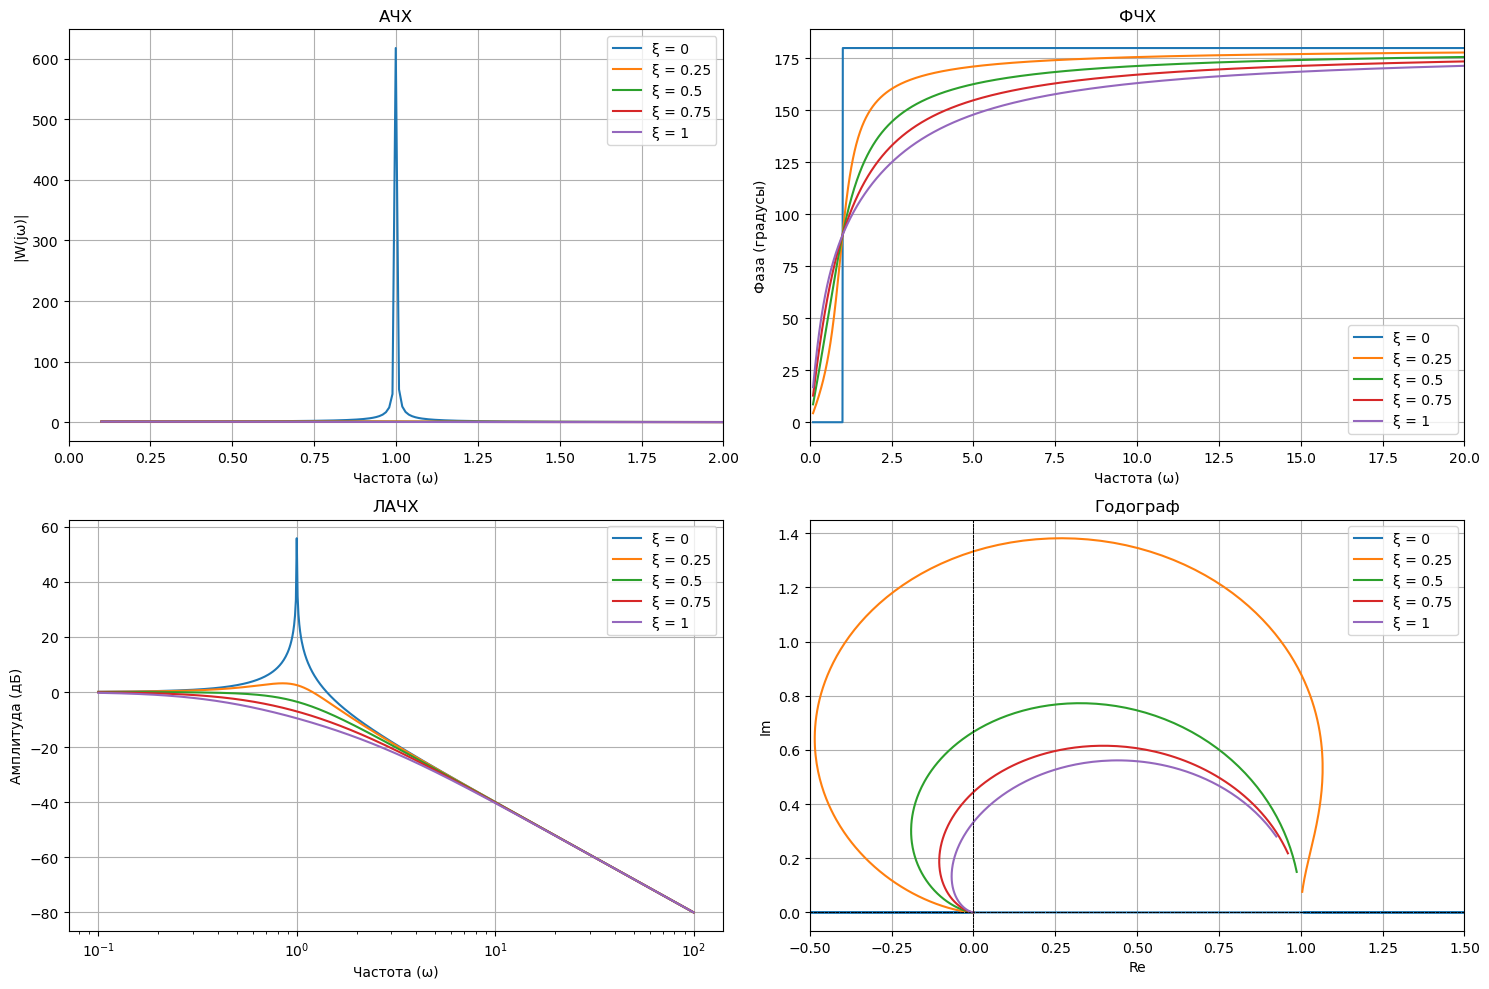

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Параметры звена
T = 1  # Постоянная времени
xi_values = [0, 0.25, 0.5, 0.75, 1]  # Разные значения коэффициента демпфирования
omega = np.linspace(0.1, 100, 10000)  # Линейная шкала частот

# Настройка графиков
plt.figure(figsize=(15, 10))

# Построение графиков для каждого xi
for xi in xi_values:
    # Вычисление действительной и мнимой частей
    numerator = 1
    denominator_real = 1 - T**2 * omega**2
    denominator_imag = 3 * T * xi * omega
    denominator = denominator_real**2 + denominator_imag**2

    Re = numerator * denominator_real / denominator
    Im = numerator * denominator_imag / denominator

    # АЧХ
    amplitude = np.sqrt(Re**2 + Im**2)

    # ФЧХ
    phase = np.arctan2(Im, Re)

    # ЛАЧХ
    lach = 20 * np.log10(amplitude)

    # Построение графиков
    # АЧХ
    plt.subplot(2, 2, 1)
    plt.plot(omega, amplitude, label=f'ξ = {xi}')
    plt.title('АЧХ')
    plt.xlabel('Частота (ω)')
    plt.ylabel('|W(jω)|')
    plt.grid()
    plt.legend()
    plt.xlim(0, 2)
    
    # ФЧХ
    plt.subplot(2, 2, 2)
    plt.plot(omega, np.degrees(phase), label=f'ξ = {xi}')
    plt.title('ФЧХ')
    plt.xlabel('Частота (ω)')
    plt.ylabel('Фаза (градусы)')
    plt.grid()
    plt.legend()
    plt.xlim(0, 20)

    # ЛАЧХ
    plt.subplot(2, 2, 3)
    plt.plot(omega, lach, label=f'ξ = {xi}')
    plt.xscale('log')
    plt.title('ЛАЧХ')
    plt.xlabel('Частота (ω)')
    plt.ylabel('Амплитуда (дБ)')
    plt.grid()
    plt.legend()

    # Годограф
    plt.subplot(2, 2, 4)
    plt.plot(Re, Im, label=f'ξ = {xi}')
    plt.title('Годограф')
    plt.xlabel('Re')
    plt.ylabel('Im')
    plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
    plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
    plt.grid()
    plt.legend()
    plt.xlim(-0.5, 1.5)

plt.tight_layout()
plt.show()